# Transfer Learning and Fine-Tuning CNNs with PyTorch

A self-contained teaching notebook for beginner deep learning students.

**Prerequisites:**
- Basic understanding of CNNs (convolution, pooling, classification)
- Basic Python experience
- Familiarity with at least one CNN training script

## Section 1: Imports and Device Setup

We start by importing all required libraries and setting up the compute device. PyTorch can run on CPU, NVIDIA GPU (CUDA), or Apple Silicon GPU (MPS). The code below automatically detects the best available device.

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader # Pytorch Utility to load data in batches
import torchvision # Pytorch's Computer Vision Library
# datasets to easily access common datasets, transforms for data augmentation and preprocessing, and models for pre-trained architectures
from torchvision import datasets, transforms, models 
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import copy # For deep copying models and other objects
from pathlib import Path # For handling file paths in a platform-independent way

# Device selection: prioritize GPU acceleration when available
def get_device():
    """
    Automatically select the best available device.
    Priority: CUDA (NVIDIA GPU) > MPS (Apple Silicon) > CPU
    """
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using MPS (Apple Silicon GPU)")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

device = get_device()

Using MPS (Apple Silicon GPU)


**Note on MPS:** Apple Silicon's Metal Performance Shaders provide GPU acceleration on M1/M2/M3 Macs. If you encounter issues, you can force CPU with `device = torch.device("cpu")`

## Section 2: Reproducibility - Setting Random Seeds

To get consistent results across runs, we set seeds for all random number generators. This helps when debugging and when comparing experiments.

In [32]:
def set_seed(seed=42):
    """Set random seeds for reproducibility across all libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # For deterministic behavior (may slow down training)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Section 3: Dataset and DataLoaders

We use CIFAR-10: 60,000 32x32 color images in 10 classes.
- Training: 50,000 images
- Test: 10,000 images

For transfer learning with ImageNet-pretrained models, we need to:
1. **Resize images to 224x224** (ImageNet input size)
2. **Normalize using ImageNet's mean and standard deviation**

These transforms ensure our small images are compatible with pretrained models.

In [33]:
# ImageNet normalization values (used for all pretrained models)
# Mean and SD of pixel values across all ImageNet images for each color channel (R, G, B)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Transforms for training data (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize(224),              # Resize to 224x224 for pretrained models
    transforms.RandomHorizontalFlip(),   # Simple augmentation
    transforms.ToTensor(),               # Convert to tensor [0, 1]
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)  # ImageNet normalization
])

# Transforms for validation/test data (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [34]:
# Download and prepare datasets
print("Downloading CIFAR-10 dataset...")
train_dataset = datasets.CIFAR10(
    root='./data', # Directory to store the dataset
    train=True, # Load training data
    download=True, # Download if not already present
    transform=train_transforms # Apply training transforms (including augmentation
)

val_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=val_transforms
)

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(class_names)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Number of classes: {num_classes}")

Training samples: 50000
Validation samples: 10000
Number of classes: 10


### Create DataLoaders

DataLoader handles batching, shuffling, and parallel data loading.
- **batch_size:** Number of samples per gradient update (32 is a good default)
- **shuffle:** Randomize order each epoch (True for training, False for validation)
- **num_workers:** Parallel data loading (set to 0 for Windows compatibility)

In [35]:
BATCH_SIZE = 128 # Common batch size for training; adjust based on GPU memory (e.g., 64 or 128 if you have more memory)

# Note: num_workers=0 for Windows compatibility; increase on Linux/Mac for speed
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # Shuffle training data each epoch
    num_workers=0, # Set to 0 for Windows; increase to 4 or more on Linux/Mac for faster loading
    pin_memory=True if device.type == 'cuda' else False # Pin memory for faster GPU transfers if using CUDA
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # No need to shuffle validation data because order does not matter for evaluation
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

## Section 4: Utility Functions

These reusable functions handle training, evaluation, and visualization. They work with any model, making it easy to compare different approaches.

In [36]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    
    Args:
        model: PyTorch model to train
        dataloader: Training data loader
        criterion: Loss function
        optimizer: Optimizer (e.g., Adam, SGD)
        device: Device to use (cuda/mps/cpu)
    
    Returns:
        Tuple of (average_loss, accuracy)
    """
    model.train()  # Set model to training mode (enables dropout, batch norm updates)
    running_loss = 0.0 # Cumulative loss for the epoch
    correct = 0 # number of correct predictions
    total = 0 # total number of samples
    
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device) # Moves data to the selected device (GPU/CPU)
        
        optimizer.zero_grad()           # Clear previous gradients
        outputs = model(inputs)         # Forward pass
        loss = criterion(outputs, labels)
        loss.backward()                 # Compute gradients
        optimizer.step()                # Update weights
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1) # Get predicted class indices for each sample
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [37]:
def evaluate(model, dataloader, criterion, device):
    """
    Evaluate the model on validation/test data.
    
    Args:
        model: PyTorch model to evaluate
        dataloader: Validation/test data loader
        criterion: Loss function
        device: Device to use
    
    Returns:
        Tuple of (average_loss, accuracy)
    """
    model.eval()  # Set model to evaluation mode (disables dropout, fixes batch norm)
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():  # Disable gradient computation for efficiency
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [38]:
def train_model(model, train_loader, val_loader, criterion, optimizer, 
                device, num_epochs, scheduler=None, model_name="Model"):
    """
    Complete training loop with validation and history tracking.
    
    Returns:
        Tuple of (trained_model, history_dict)
    """
    # History dictionary to store loss and accuracy for each epoch
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        # Training phase
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validation phase
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        # Update learning rate if scheduler is provided
        if scheduler:
            scheduler.step()
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
        
        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch+1:2d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.1f}s")
    
    total_time = time.time() - start_time
    print(f"\nTraining complete in {total_time/60:.1f} minutes")
    print(f"Best validation accuracy: {best_acc:.2f}%")
    
    # Load best model weights
    model.load_state_dict(best_model_weights)
    
    return model, history

In [39]:
def plot_curves(history, title="Training History"):
    """
    Plot training and validation loss/accuracy curves.
    
    Args:
        history: Dictionary with 'train_loss', 'val_loss', 'train_acc', 'val_acc'
        title: Plot title
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

In [40]:
def show_predictions(model, dataloader, class_names, device, num_images=8):
    """
    Display sample images with predicted and true labels.
    """
    model.eval()
    images_shown = 0
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten() # Flatten to easily index subplots
    
    # Denormalize for display
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            for i in range(inputs.size(0)):
                if images_shown >= num_images:
                    break
                
                # Denormalize image
                img = inputs[i].cpu() * std + mean
                img = img.permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)
                
                true_label = class_names[labels[i]]
                pred_label = class_names[predicted[i]]
                color = 'green' if true_label == pred_label else 'red'
                
                axes[images_shown].imshow(img)
                axes[images_shown].set_title(f'True: {true_label}\nPred: {pred_label}', 
                                             color=color, fontsize=10)
                axes[images_shown].axis('off')
                images_shown += 1
            
            if images_shown >= num_images:
                break
    
    plt.tight_layout()
    plt.show()

## Section 5: Transfer Learning - Feature Extractor (Frozen Backbone)

### Key Concepts

1. **Pretrained models** (like ResNet18) were trained on ImageNet (1.4M images, 1000 classes). They've learned general visual features: edges, textures, shapes, and object parts.

2. **Feature extraction:** We use the pretrained model as a fixed feature extractor by **freezing** all its layers. Only the final classification layer is trainable.

3. **Why it works:** The learned features from ImageNet transfer well to other image tasks. Our small dataset benefits from these pretrained features instead of learning from scratch.

4. **Key steps:**
   - Load pretrained model
   - Replace final layer to match our number of classes
   - Freeze all pretrained layers (`requires_grad=False`)
   - Train only the new final layer

In [41]:
# Load pretrained ResNet18
# weights=IMAGENET1K_V1 loads the ImageNet pretrained weights
feature_extractor = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Examine the model structure (helps understand what to modify)
print("Original ResNet18 final layer (fc):")
print(feature_extractor.fc)

Original ResNet18 final layer (fc):
Linear(in_features=512, out_features=1000, bias=True)


In [42]:
# STEP 1: Freeze all pretrained layers
# When requires_grad=False, the layer's weights won't be updated during training
for param in feature_extractor.parameters():
    param.requires_grad = False

# STEP 2: Replace the final fully connected layer
# ResNet18's fc layer expects 512 input features, outputs 1000 (ImageNet classes)
# We replace it with a new layer that outputs num_classes (10 for CIFAR-10)
num_features = feature_extractor.fc.in_features  # Get input size (512 for ResNet18)
feature_extractor.fc = nn.Linear(num_features, num_classes)  # New layer, trainable by default

print(f"New final layer: Linear({num_features}, {num_classes})")

New final layer: Linear(512, 10)


In [43]:
# Move model to device
feature_extractor = feature_extractor.to(device)

# Count trainable vs total parameters
total_params = sum(p.numel() for p in feature_extractor.parameters())
trainable_params = sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

Total parameters: 11,181,642
Trainable parameters: 5,130 (0.05%)


In [44]:
# STEP 3: Set up optimizer - only optimize the new head (fc layer)
# Since other layers are frozen, we only need to pass the trainable parameters
criterion = nn.CrossEntropyLoss()
optimizer_fe = optim.Adam(feature_extractor.fc.parameters(), lr=0.001)

# Train the feature extractor
FEATURE_EXTRACTOR_EPOCHS = 5

feature_extractor, fe_history = train_model(
    model=feature_extractor,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_fe,
    device=device,
    num_epochs=FEATURE_EXTRACTOR_EPOCHS,
    model_name="ResNet18 Feature Extractor (Frozen)"
)


Training: ResNet18 Feature Extractor (Frozen)
Epoch  1/5 | Train Loss: 0.9034 Acc: 71.17% | Val Loss: 0.6574 Acc: 78.31% | Time: 104.2s
Epoch  2/5 | Train Loss: 0.6245 Acc: 78.87% | Val Loss: 0.6045 Acc: 79.92% | Time: 102.9s
Epoch  3/5 | Train Loss: 0.5914 Acc: 79.77% | Val Loss: 0.5839 Acc: 80.47% | Time: 103.8s
Epoch  4/5 | Train Loss: 0.5679 Acc: 80.45% | Val Loss: 0.5752 Acc: 80.62% | Time: 99.5s
Epoch  5/5 | Train Loss: 0.5609 Acc: 80.75% | Val Loss: 0.5731 Acc: 80.58% | Time: 103.4s

Training complete in 8.6 minutes
Best validation accuracy: 80.62%


**In Each Epoch:**
The model sees all 50,000 training images (in batches of 32)
For each batch:
- Images pass through frozen conv layers (features extracted)
- Features pass through trainable fully connected layer (classification)
- Loss is computed, gradients are computed for fully connected layer only
- fc weights are updated

After training batches, evaluation is done on all 10,000 validation images

Notice how quickly this trains! With only the final layer being updated, we're leveraging all the pretrained feature representations.

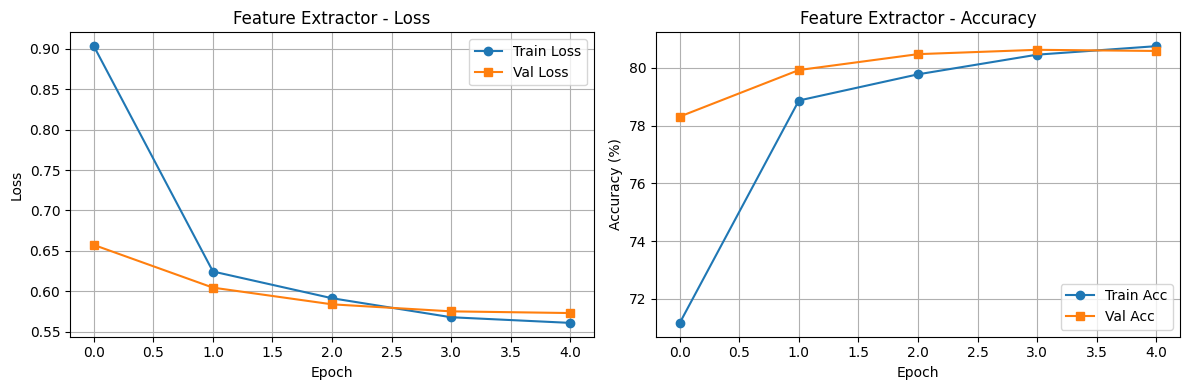

In [45]:
plot_curves(fe_history, "Feature Extractor")

## Section 6: Fine-Tuning - Unfreezing Some Layers

### Key Concepts

1. After feature extraction training, we can **unfreeze** some pretrained layers to fine-tune them on our specific dataset.

2. **Why fine-tune?**
   - Pretrained features are generic; fine-tuning adapts them to our domain
   - Can improve accuracy beyond feature extraction alone
   - Allows the model to learn dataset-specific patterns

3. **Best practices:**
   - Start with frozen training first (feature extraction)
   - Unfreeze gradually (later layers first - they're more task-specific)
   - Use a **lower learning rate** for pretrained layers (they're already good)
   - Use a **higher learning rate** for the new head (needs more training)

4. **ResNet18 structure** (layers to consider unfreezing):
   - `conv1, bn1, relu, maxpool` - early layers, very generic features
   - `layer1, layer2` - mid layers, increasingly specific
   - `layer3, layer4` - later layers, more task-specific, good to unfreeze
   - `fc` - our new classification head

In [46]:
# Start fresh with a new pretrained model
fine_tuned_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace the final layer first
num_features = fine_tuned_model.fc.in_features
fine_tuned_model.fc = nn.Linear(num_features, num_classes)

In [47]:
# STRATEGY: Unfreeze layer4 and fc, keep everything else frozen
# This gives us the best balance of pretrained knowledge and adaptability

# First, freeze everything
for param in fine_tuned_model.parameters():
    param.requires_grad = False

# Unfreeze layer4 (the last residual block)
for param in fine_tuned_model.layer4.parameters():
    param.requires_grad = True

# Unfreeze fc (our new classification head) - already unfrozen since we just created it
for param in fine_tuned_model.fc.parameters():
    param.requires_grad = True

fine_tuned_model = fine_tuned_model.to(device)

In [48]:
# Count parameters again
total_params = sum(p.numel() for p in fine_tuned_model.parameters())
trainable_params = sum(p.numel() for p in fine_tuned_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

Total parameters: 11,181,642
Trainable parameters: 8,398,858 (75.11%)


In [49]:
# DIFFERENT LEARNING RATES for different parameter groups
# Lower LR for pretrained layers (0.0001) - they're already well-trained
# Higher LR for new head (0.001) - needs to learn from scratch

# Create parameter groups with different learning rates
optimizer_ft = optim.Adam([
    {'params': fine_tuned_model.layer4.parameters(), 'lr': 0.0001},  # Lower LR for pretrained
    {'params': fine_tuned_model.fc.parameters(), 'lr': 0.001}        # Higher LR for new head
])

print("Learning rates:")
print("  - layer4 (pretrained): 0.0001")
print("  - fc (new head): 0.001")

Learning rates:
  - layer4 (pretrained): 0.0001
  - fc (new head): 0.001


In [ ]:
# Optional: Learning rate scheduler to reduce LR over time
scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=3, gamma=0.5) 
# gamma = 0.5 multiplies the learning rate by 0.5 (halves it) every step_size epochs (every 3 epochs in this case)

# Train the fine-tuned model
FINE_TUNE_EPOCHS = 5

fine_tuned_model, ft_history = train_model(
    model=fine_tuned_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_ft,
    device=device,
    num_epochs=FINE_TUNE_EPOCHS,
    scheduler=scheduler_ft,
    model_name="ResNet18 Fine-Tuned (layer4 + fc)"
)


Training: ResNet18 Fine-Tuned (layer4 + fc)
Epoch  1/5 | Train Loss: 0.4375 Acc: 85.12% | Val Loss: 0.3106 Acc: 89.51% | Time: 125.2s
Epoch  2/5 | Train Loss: 0.1952 Acc: 93.42% | Val Loss: 0.2844 Acc: 90.50% | Time: 124.7s
Epoch  3/5 | Train Loss: 0.1157 Acc: 96.13% | Val Loss: 0.2840 Acc: 91.25% | Time: 127.4s
Epoch  4/5 | Train Loss: 0.0595 Acc: 98.20% | Val Loss: 0.2669 Acc: 91.74% | Time: 125.6s
Epoch  5/5 | Train Loss: 0.0362 Acc: 99.00% | Val Loss: 0.2786 Acc: 91.84% | Time: 133.2s

Training complete in 10.6 minutes
Best validation accuracy: 91.84%


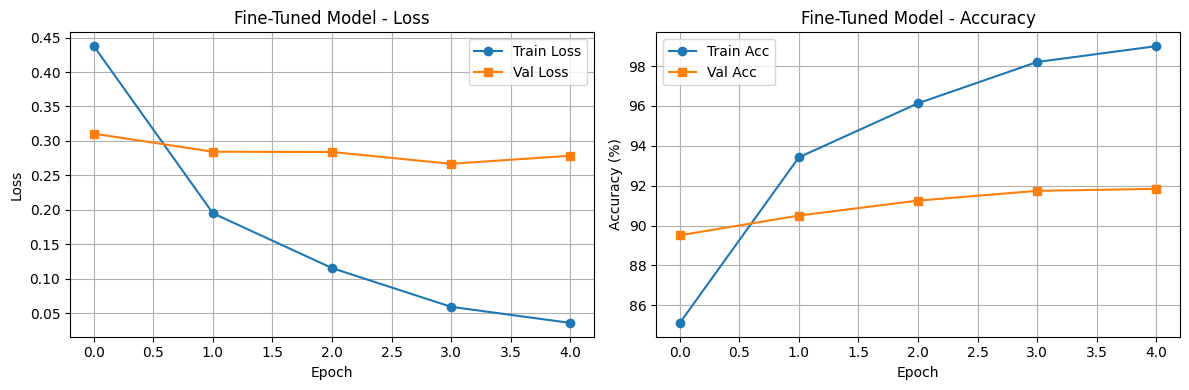

In [51]:
plot_curves(ft_history, "Fine-Tuned Model")

### Tips for Adapting to Other Datasets

- **Similar domains** (natural images): Unfreeze just `layer4 + fc`
- **Different domains** (medical, satellite): Unfreeze more layers (`layer3, layer4, fc`)
- **Very small datasets**: Keep more layers frozen to prevent overfitting
- **Larger datasets**: Can unfreeze more or all layers

To unfreeze ALL layers for full fine-tuning:
```python
for param in model.parameters():
    param.requires_grad = True
```

## Section 7: Comparison and Visualization

Let's compare both transfer learning approaches:
1. Feature Extractor (frozen pretrained backbone)
2. Fine-tuned Model (partially unfrozen)

In [52]:
# Get final validation accuracies
fe_val_acc = fe_history['val_acc'][-1]
ft_val_acc = ft_history['val_acc'][-1]

print("="*60)
print("RESULTS COMPARISON")
print("="*60)
print(f"\nFinal Validation Accuracy:")
print(f"  1. Feature Extractor (frozen):    {fe_val_acc:.2f}%")
print(f"  2. Fine-tuned (layer4 + fc):      {ft_val_acc:.2f}%")
print(f"\nImprovement from fine-tuning: {ft_val_acc - fe_val_acc:+.2f}%")

RESULTS COMPARISON

Final Validation Accuracy:
  1. Feature Extractor (frozen):    80.58%
  2. Fine-tuned (layer4 + fc):      91.84%

Improvement from fine-tuning: +11.26%


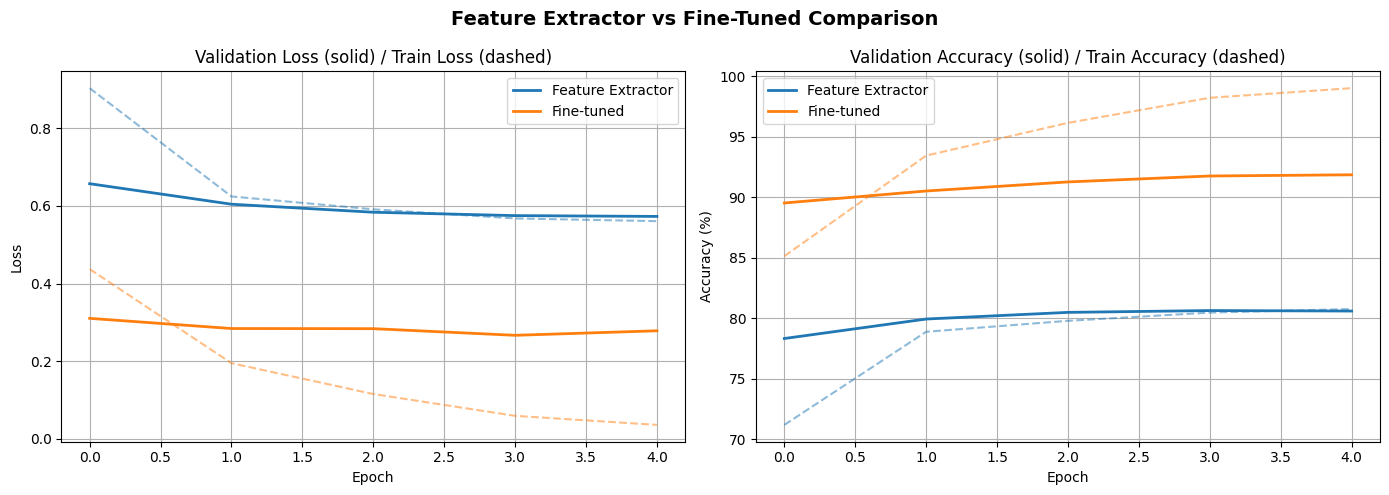

In [53]:
def plot_comparison(histories, labels, title="Model Comparison"):
    """Plot multiple training histories for comparison."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for i, (history, label) in enumerate(zip(histories, labels)):
        # Loss
        axes[0].plot(history['train_loss'], '--', color=colors[i], alpha=0.5)
        axes[0].plot(history['val_loss'], '-', color=colors[i], label=label, linewidth=2)
        
        # Accuracy
        axes[1].plot(history['train_acc'], '--', color=colors[i], alpha=0.5)
        axes[1].plot(history['val_acc'], '-', color=colors[i], label=label, linewidth=2)
    
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Validation Loss (solid) / Train Loss (dashed)')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Validation Accuracy (solid) / Train Accuracy (dashed)')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_comparison(
    [fe_history, ft_history],
    ['Feature Extractor', 'Fine-tuned'],
    "Feature Extractor vs Fine-Tuned Comparison"
)

Sample predictions from fine-tuned model:


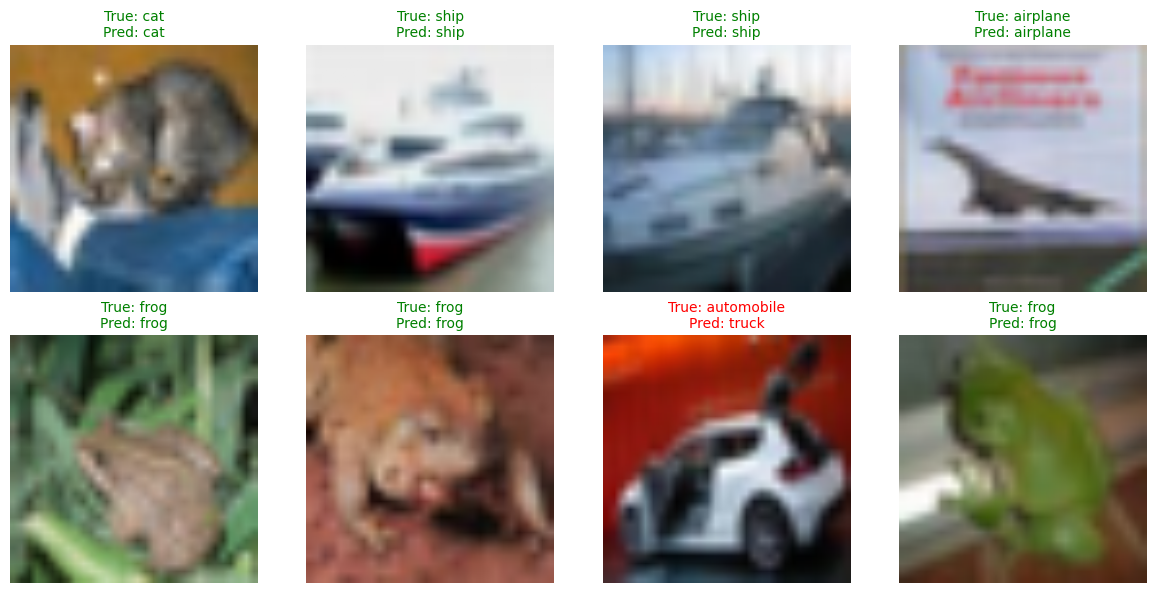

In [54]:
# Show sample predictions from the fine-tuned model
print("Sample predictions from fine-tuned model:")
show_predictions(fine_tuned_model, val_loader, class_names, device)

### What to Observe

1. **Feature extractor** trains very quickly because only the final layer is being updated.

2. **Fine-tuning** can squeeze out extra performance by adapting pretrained features to the specific dataset.

3. The gap between methods depends on:
   - Dataset size (smaller = bigger advantage for transfer learning)
   - Domain similarity to ImageNet (closer = better transfer)
   - Number of epochs

## Section 8: Saving and Loading Models

After training, you'll want to save your best model for later use. PyTorch offers two main approaches:

1. **Save state_dict (RECOMMENDED):**
   - Saves only the learned parameters (weights and biases)
   - Smaller file size
   - More flexible (can load into modified architectures)

2. **Save entire model:**
   - Saves architecture + parameters
   - Simpler but less portable

In [55]:
# Create a directory for saved models
save_dir = Path("saved_models")
save_dir.mkdir(exist_ok=True)

# METHOD 1: Save state_dict (recommended)
model_path = save_dir / "resnet18_finetuned_cifar10.pth"
torch.save(fine_tuned_model.state_dict(), model_path)
print(f"Model state_dict saved to: {model_path}")

Model state_dict saved to: saved_models/resnet18_finetuned_cifar10.pth


In [60]:
# How to load it back:
def load_model_for_inference(model_path, num_classes=10, device='cpu'):
    """
    Load a saved model for inference.
    
    Steps:
    1. Create the same architecture
    2. Load the saved weights
    3. Set to evaluation mode
    """
    # Create model with same architecture
    model = models.resnet18(weights=None)  # No pretrained weights
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    # Load saved weights
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    
    # Set to evaluation mode (disables dropout, etc.)
    model.eval()
    model = model.to(device)
    
    return model

# Demonstrate loading
print("Loading model from disk...")
loaded_model = load_model_for_inference(model_path, num_classes=num_classes, device=device)

# Verify it works
val_loss, val_acc = evaluate(loaded_model, val_loader, criterion, device)
print(f"Loaded model validation accuracy: {val_acc:.2f}%")

Loading model from disk...
Loaded model validation accuracy: 91.84%


In [57]:
# METHOD 2: Save with additional metadata (useful for resuming training)
checkpoint_path = save_dir / "checkpoint.pth"
checkpoint = {
    'model_state_dict': fine_tuned_model.state_dict(),
    'optimizer_state_dict': optimizer_ft.state_dict(),
    'epoch': FINE_TUNE_EPOCHS,
    'best_val_acc': ft_val_acc,
    'class_names': class_names,
}
torch.save(checkpoint, checkpoint_path)
print(f"Full checkpoint saved to: {checkpoint_path}")

Full checkpoint saved to: saved_models/checkpoint.pth


In [61]:
### Loading a Checkpoint to Resume Training

# checkpoint = torch.load(checkpoint_path)
# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# start_epoch = checkpoint['epoch']


## Section 9: Running Inference on New Images

To use your trained model on new images, you need to:
1. Apply the same transforms used during training/validation
2. Add a batch dimension (model expects batches)
3. Run forward pass and get predictions

In [62]:
def predict_single_image(model, image_tensor, class_names, device):
    """
    Predict class for a single image tensor.
    
    Args:
        model: Trained model (in eval mode)
        image_tensor: Preprocessed image tensor [C, H, W]
        class_names: List of class names
        device: Device to use
    
    Returns:
        Tuple of (predicted_class, confidence)
    """
    model.eval()
    
    # Add batch dimension: [C, H, W] -> [1, C, H, W]
    image_batch = image_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(image_batch)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted_idx = probabilities.max(1)
    
    predicted_class = class_names[predicted_idx.item()]
    confidence = confidence.item() * 100
    
    return predicted_class, confidence


# Example: predict on a validation image
sample_image, true_label = val_dataset[0]
predicted_class, confidence = predict_single_image(
    loaded_model, sample_image, class_names, device
)
print(f"Example inference:")
print(f"  True label: {class_names[true_label]}")
print(f"  Predicted: {predicted_class} ({confidence:.1f}% confidence)")

Example inference:
  True label: cat
  Predicted: cat (98.1% confidence)


In [67]:
from PIL import Image

# Define transforms (same as validation)
inference_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load and preprocess image
image = Image.open("airplane.jpg").convert("RGB")
image_tensor = inference_transforms(image)

# Predict
predicted_class, confidence = predict_single_image(
    loaded_model, image_tensor, class_names, device
)


print(f"  Predicted: {predicted_class} ({confidence:.1f}% confidence)")

  Predicted: bird (72.6% confidence)


### Using on Your Own Images

```python
from PIL import Image

# Define transforms (same as validation)
inference_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load and preprocess image
image = Image.open("your_image.jpg").convert("RGB")
image_tensor = inference_transforms(image)

# Predict
predicted_class, confidence = predict_single_image(
    loaded_model, image_tensor, class_names, device
)
```

## Summary: Key Takeaways

### Transfer Learning Workflow

**1. FEATURE EXTRACTION (Quick, good baseline):**
- Load pretrained model
- Freeze all layers: `param.requires_grad = False`
- Replace final layer to match your classes
- Train only the new layer

**2. FINE-TUNING (Better accuracy):**
- Start from feature extractor
- Unfreeze some later layers
- Use lower LR for pretrained layers (they're already good)
- Use higher LR for new layers (they need to learn)

### Key Code Patterns

```python
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze specific layers
for param in model.layer4.parameters():
    param.requires_grad = True

# Different learning rates
optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 0.0001},
    {'params': model.fc.parameters(), 'lr': 0.001}
])

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)
```

### When to Use What

| Scenario | Approach |
|----------|----------|
| Small dataset, similar to ImageNet | Feature extraction |
| Small dataset, different domain | Fine-tune more layers |
| Large dataset | Fine-tune all or train from scratch |
| Quick prototyping | Feature extraction first |

### Adapting to Other Models

| Model | Final Layer |
|-------|-------------|
| ResNet | `model.fc` |
| VGG | `model.classifier[-1]` |
| EfficientNet | `model.classifier[-1]` |
| MobileNet | `model.classifier[-1]` |

Check model structure with: `print(model)`

In [59]:
print("\n✓ Notebook complete!")
print("  Generated files:")
print("  - saved_models/resnet18_finetuned_cifar10.pth")
print("  - saved_models/checkpoint.pth")


✓ Notebook complete!
  Generated files:
  - saved_models/resnet18_finetuned_cifar10.pth
  - saved_models/checkpoint.pth
